In [1]:
#Question 1: With Code - At Home vs. Eating Out

Columns in dataset:
Index(['year',
       'food_sales_at_grocery_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_convenience_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_other_food_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_warehouse_clubs_and_supercenters_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_other_stores_and_foodservice_(millions_of_nominal_u.s._dollars)',
       'direct_food_selling_by_farmers,_manufacturers,_and_wholesalers_(millions_of_nominal_u.s._dollars)',
       'home_food_production_and_donations_(millions_of_nominal_u.s._dollars)',
       'total_food_at_home_expenditures_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_full_service_restaurants_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_limited_service_restaurants_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_drinking_places_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_hotels_and_motels_(mill

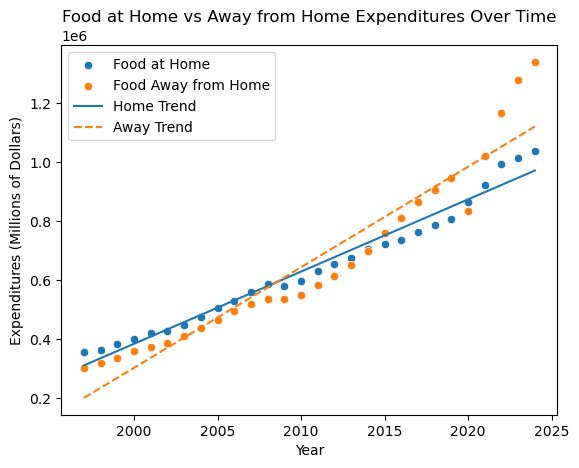


Growth Rates (Slope):
Food at Home: 24428.83536124795
Food Away from Home: 34013.66510399562


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

df = pd.read_csv("nominal_expenditures_no_taxes_tips.csv", header=0)

df.columns = [
    str(col).strip().lower().replace(" ", "_").replace("-", "_")
    for col in df.columns
]

df = df.loc[:, ~df.columns.str.contains("^unnamed")]

print("Columns in dataset:")
print(df.columns)

home_col = [col for col in df.columns if "food_at_home" in col][0]
away_col = [col for col in df.columns if "food_away_from_home" in col][0]

print("\nDetected columns:")
print("Home:", home_col)
print("Away:", away_col)

data = df[["year", home_col, away_col]].copy()
data.columns = ["year", "food_home", "food_away"]

def clean_numeric(series):
    return (
        series.astype(str)
        .str.replace(",", "", regex=False)   # remove commas
        .str.replace(r"[^\d.]", "", regex=True)  # remove anything not digit or dot
    )

data["year"] = pd.to_numeric(clean_numeric(data["year"]), errors="coerce")
data["food_home"] = pd.to_numeric(clean_numeric(data["food_home"]), errors="coerce")
data["food_away"] = pd.to_numeric(clean_numeric(data["food_away"]), errors="coerce")

data = data.dropna()

print("\nNumber of valid rows after cleaning:", len(data))
print(data.head())

if len(data) == 0:
    raise ValueError("Still no data — file may have unexpected formatting.")

X = data["year"].values.reshape(-1, 1)

home_model = LinearRegression().fit(X, data["food_home"])
away_model = LinearRegression().fit(X, data["food_away"])

home_trend = home_model.predict(X)
away_trend = away_model.predict(X)

plt.figure()

sns.scatterplot(x=data["year"], y=data["food_home"], label="Food at Home")
sns.scatterplot(x=data["year"], y=data["food_away"], label="Food Away from Home")

plt.plot(data["year"], home_trend, label="Home Trend")
plt.plot(data["year"], away_trend, linestyle="--", label="Away Trend")

plt.title("Food at Home vs Away from Home Expenditures Over Time")
plt.xlabel("Year")
plt.ylabel("Expenditures (Millions of Dollars)")
plt.legend()

plt.show()

print("\nGrowth Rates (Slope):")
print("Food at Home:", home_model.coef_[0])
print("Food Away from Home:", away_model.coef_[0])

In [ ]:
#Question 2: With Code - At Home vs. Out Alchohol

Columns in dataset:
Index(['year',
       'food_sales_at_grocery_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_convenience_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_other_food_stores_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_warehouse_clubs_and_supercenters_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_other_stores_and_foodservice_(millions_of_nominal_u.s._dollars)',
       'direct_food_selling_by_farmers,_manufacturers,_and_wholesalers_(millions_of_nominal_u.s._dollars)',
       'home_food_production_and_donations_(millions_of_nominal_u.s._dollars)',
       'total_food_at_home_expenditures_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_full_service_restaurants_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_limited_service_restaurants_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_drinking_places_(millions_of_nominal_u.s._dollars)',
       'food_sales_at_hotels_and_motels_(mill

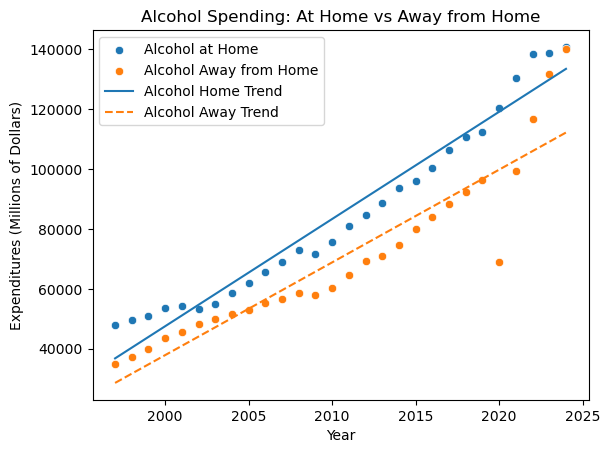


Growth Rates (Slope of Linear Regression):
Alcohol at Home: 3578.268368910784
Alcohol Away from Home: 3094.622249589491


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

df = pd.read_csv("nominal_expenditures_no_taxes_tips.csv", header=0)

df.columns = [
    str(col).strip().lower().replace(" ", "_").replace("-", "_")
    for col in df.columns
]

df = df.loc[:, ~df.columns.str.contains("^unnamed")]

print("Columns in dataset:")
print(df.columns)

alcohol_home_col = [col for col in df.columns if "total_alcohol_at_home" in col][0]
alcohol_away_col = [col for col in df.columns if "total_alcohol_away_from_home" in col][0]

print("\nDetected columns:")
print("Alcohol Home:", alcohol_home_col)
print("Alcohol Away:", alcohol_away_col)

data = df[["year", alcohol_home_col, alcohol_away_col]].copy()
data.columns = ["year", "alcohol_home", "alcohol_away"]

def clean_numeric(series):
    return (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace(r"[^\d.]", "", regex=True)
    )

data["year"] = pd.to_numeric(clean_numeric(data["year"]), errors="coerce")
data["alcohol_home"] = pd.to_numeric(clean_numeric(data["alcohol_home"]), errors="coerce")
data["alcohol_away"] = pd.to_numeric(clean_numeric(data["alcohol_away"]), errors="coerce")

data = data.dropna()

print("\nNumber of valid rows:", len(data))
print(data.head())

if len(data) == 0:
    raise ValueError("No valid data after cleaning.")

X = data["year"].values.reshape(-1, 1)

alcohol_home_model = LinearRegression().fit(X, data["alcohol_home"])
alcohol_away_model = LinearRegression().fit(X, data["alcohol_away"])

alcohol_home_trend = alcohol_home_model.predict(X)
alcohol_away_trend = alcohol_away_model.predict(X)

plt.figure()

sns.scatterplot(x=data["year"], y=data["alcohol_home"], label="Alcohol at Home")
sns.scatterplot(x=data["year"], y=data["alcohol_away"], label="Alcohol Away from Home")

plt.plot(data["year"], alcohol_home_trend, label="Alcohol Home Trend")
plt.plot(data["year"], alcohol_away_trend, linestyle="--", label="Alcohol Away Trend")

plt.title("Alcohol Spending: At Home vs Away from Home")
plt.xlabel("Year")
plt.ylabel("Expenditures (Millions of Dollars)")
plt.legend()

plt.show()

print("\nGrowth Rates (Slope of Linear Regression):")
print("Alcohol at Home:", alcohol_home_model.coef_[0])
print("Alcohol Away from Home:", alcohol_away_model.coef_[0])